# A2-02 · Image Segmentation — do skip connections matter?

Two **U-Net** decoders share the *same* ImageNet-pretrained **ResNet-18** encoder; the only difference is whether each decoder stage concatenates the matching encoder feature map (**skip connections**). Training both on Oxford-IIIT Pet for 20 epochs isolates exactly what skip connections contribute.

In [1]:
import os, sys, json
# Run from the repository root so all paths match run.py / script.* .
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
import torch, numpy as np, pandas as pd
from IPython.display import Image, display

def show(path, width=None):
    if os.path.exists(path):
        display(Image(path, width=width))
    else:
        print(f'[figure not generated yet: {path}] — run: python make_figures.py')

def load_history(tag):
    p = f'checkpoints/history_{tag}.json'
    return json.load(open(p)) if os.path.exists(p) else None

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')


device: cuda | NVIDIA GeForce RTX 5060 Ti


## 1. Semantic vs instance segmentation

| | Semantic | Instance |
|---|---|---|
| Question | class of each pixel | which *object* each pixel belongs to |
| Same-class objects | merged | separated |
| Typical model | **U-Net / FCN** | **Mask R-CNN** |

Mask R-CNN = Faster R-CNN + a per-instance mask head (RoI-**Align**, 28×28 mask). Pretrained COCO Mask R-CNN on the test image:

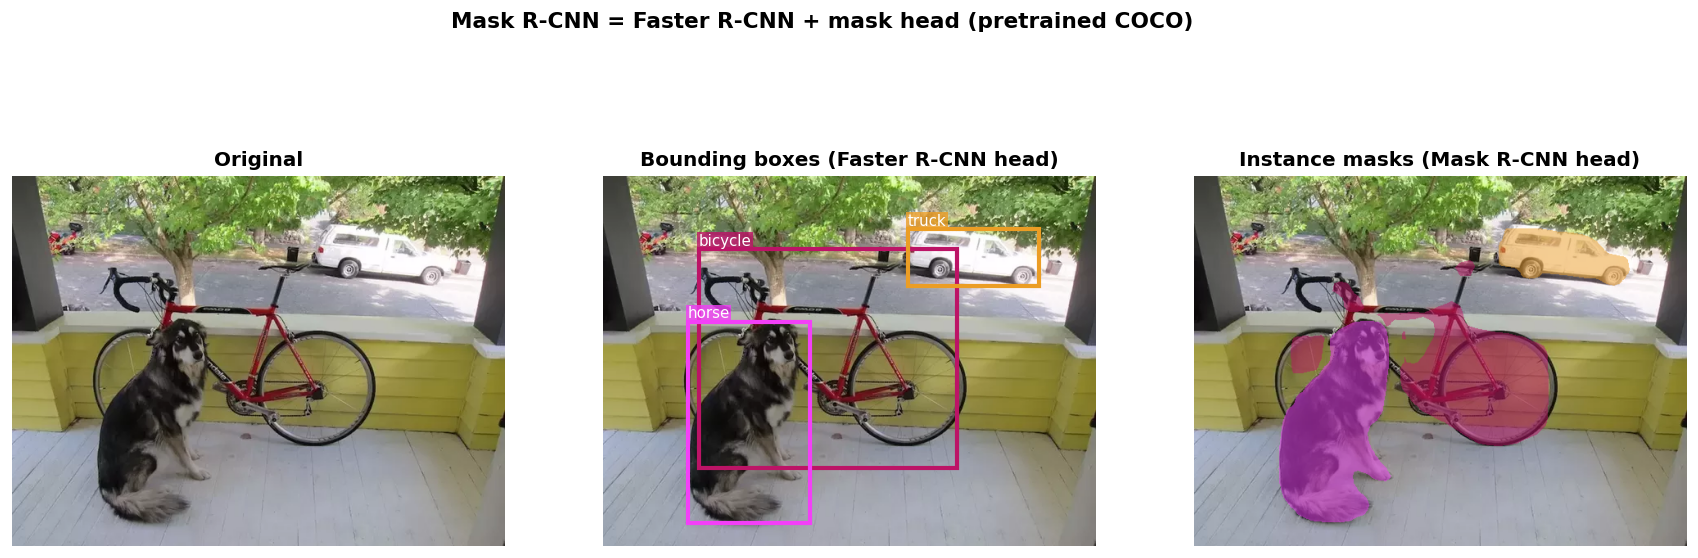

In [2]:
show('results/maskrcnn_demo.png', width=950)

## 2. U-Net + ResNet-18, and the skip ablation

The ResNet-18 encoder produces feature maps at H/2, H/4, H/8, H/16, H/32; the decoder upsamples back to full resolution in 5 stages, each (optionally) concatenating the encoder map at the same resolution. The course U-Net diagram — grey arrows are the skip connections:

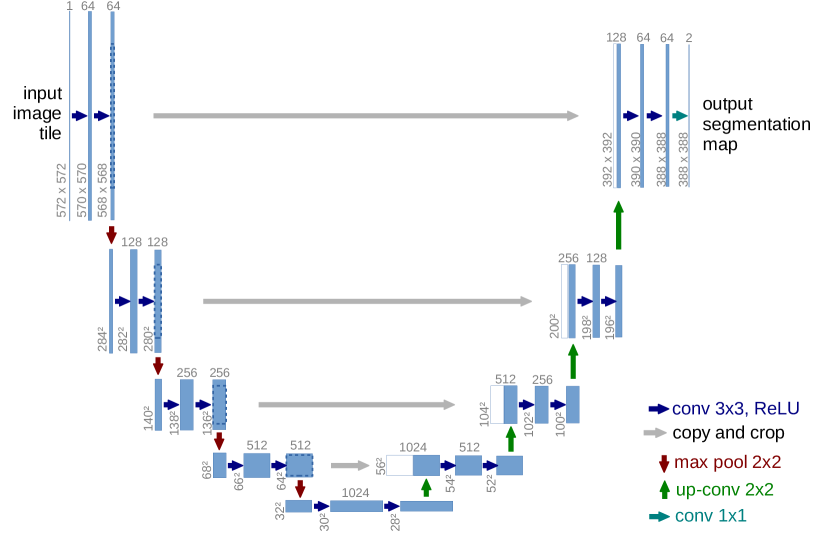

In [3]:
show('lab_note/img/unet_arch.png', width=720)

In [4]:
from segmentation.models import build_segmentation_model
for name in ['unet_resnet18','unet_resnet18_no_skip']:
    mdl = build_segmentation_model(name, pretrained=False)
    p = sum(x.numel() for x in mdl.parameters())
    print(f'{name:24s} use_skip={mdl.use_skip!s:5s} params={p:,}')

unet_resnet18            use_skip=True  params=37,572,099
unet_resnet18_no_skip    use_skip=False params=34,420,227


## 3. Dataset — Oxford-IIIT Pet (pet / background / border)

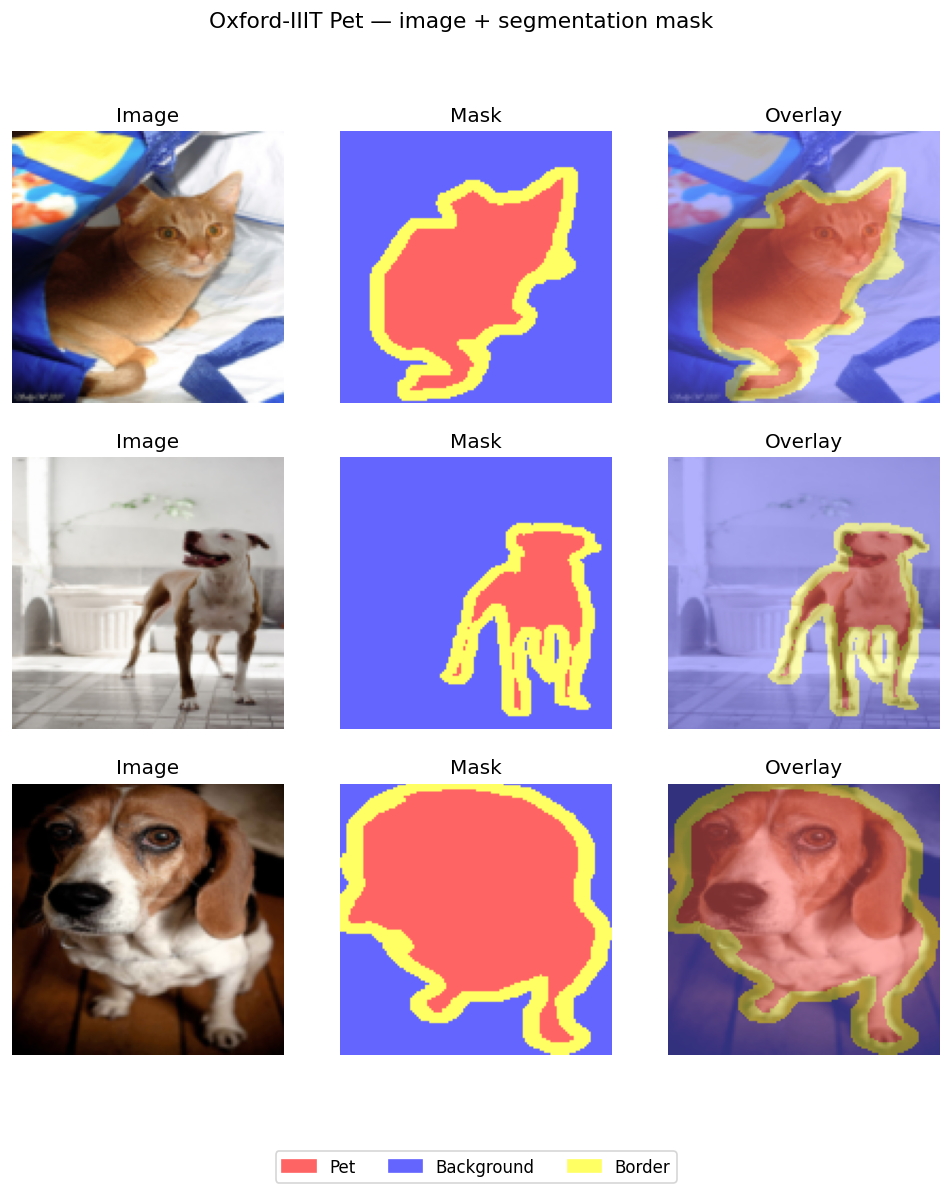

In [5]:
show('results/seg_dataset_samples.png', width=560)

## 4. Training & results (20 epochs each)

```bash
python run.py --model unet_resnet18         --dataset oxford_pet --epochs 20 --train
python run.py --model unet_resnet18_no_skip --dataset oxford_pet --epochs 20 --train
```

In [6]:
hs, hn = load_history('unet_resnet18'), load_history('unet_resnet18_no_skip')
if hs and hn:
    tbl = pd.DataFrame({
        'Model':['U-Net + ResNet-18 (skip)','U-Net + ResNet-18 (no skip)'],
        'Skip connections':['Yes','No'],
        'Best Val mIoU':[round(max(hs['miou']),4), round(max(hn['miou']),4)],
        'Time/epoch (s)':[round(np.mean(hs['time']),1), round(np.mean(hn['time']),1)]})
    display(tbl)
    print(f"skip improves mIoU by {max(hs['miou'])-max(hn['miou']):+.4f}")
else:
    print('histories not found yet — run the two training commands above')

,Model,Skip connections,Best Val mIoU,Time/epoch (s)
0,U-Net + ResNet-18 (skip),Yes,0.7594,18.2
1,U-Net + ResNet-18 (no skip),No,0.6900,16.5


skip improves mIoU by +0.0694


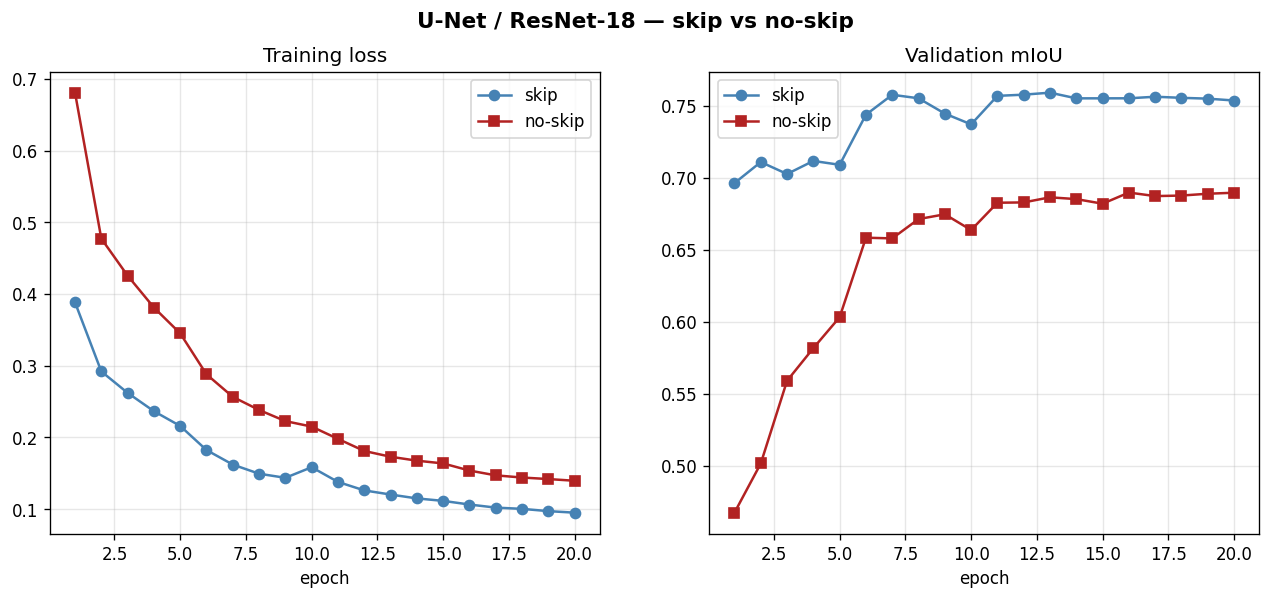

In [7]:
show('results/seg_curves.png', width=900)

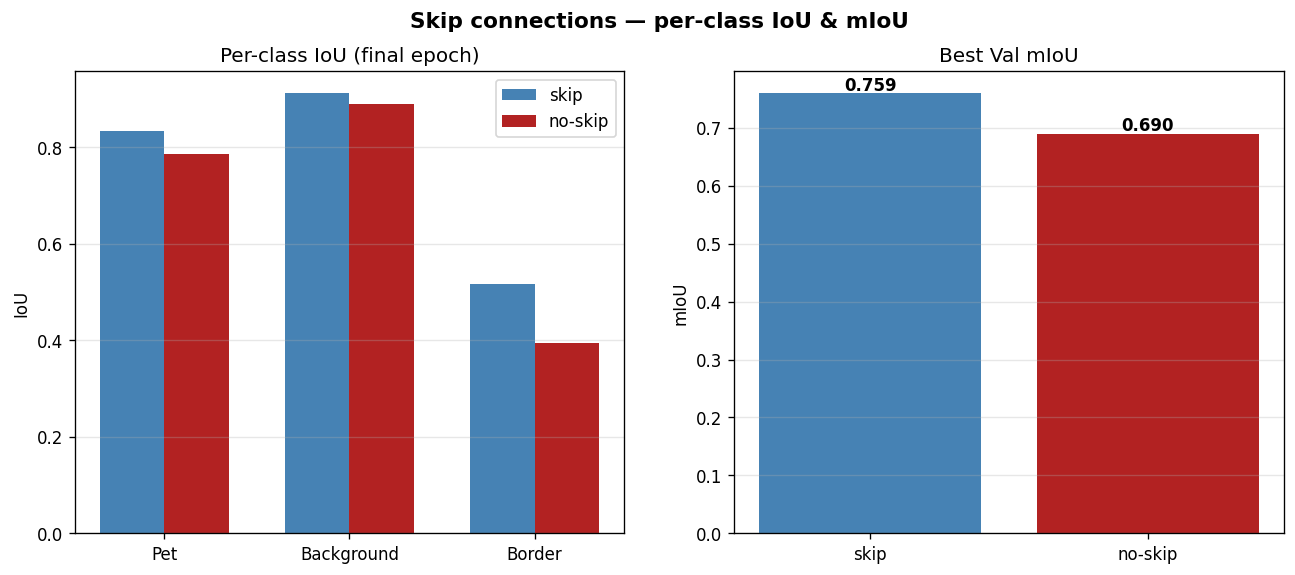

In [8]:
show('results/seg_per_class_iou.png', width=900)

### Predictions — skip variant

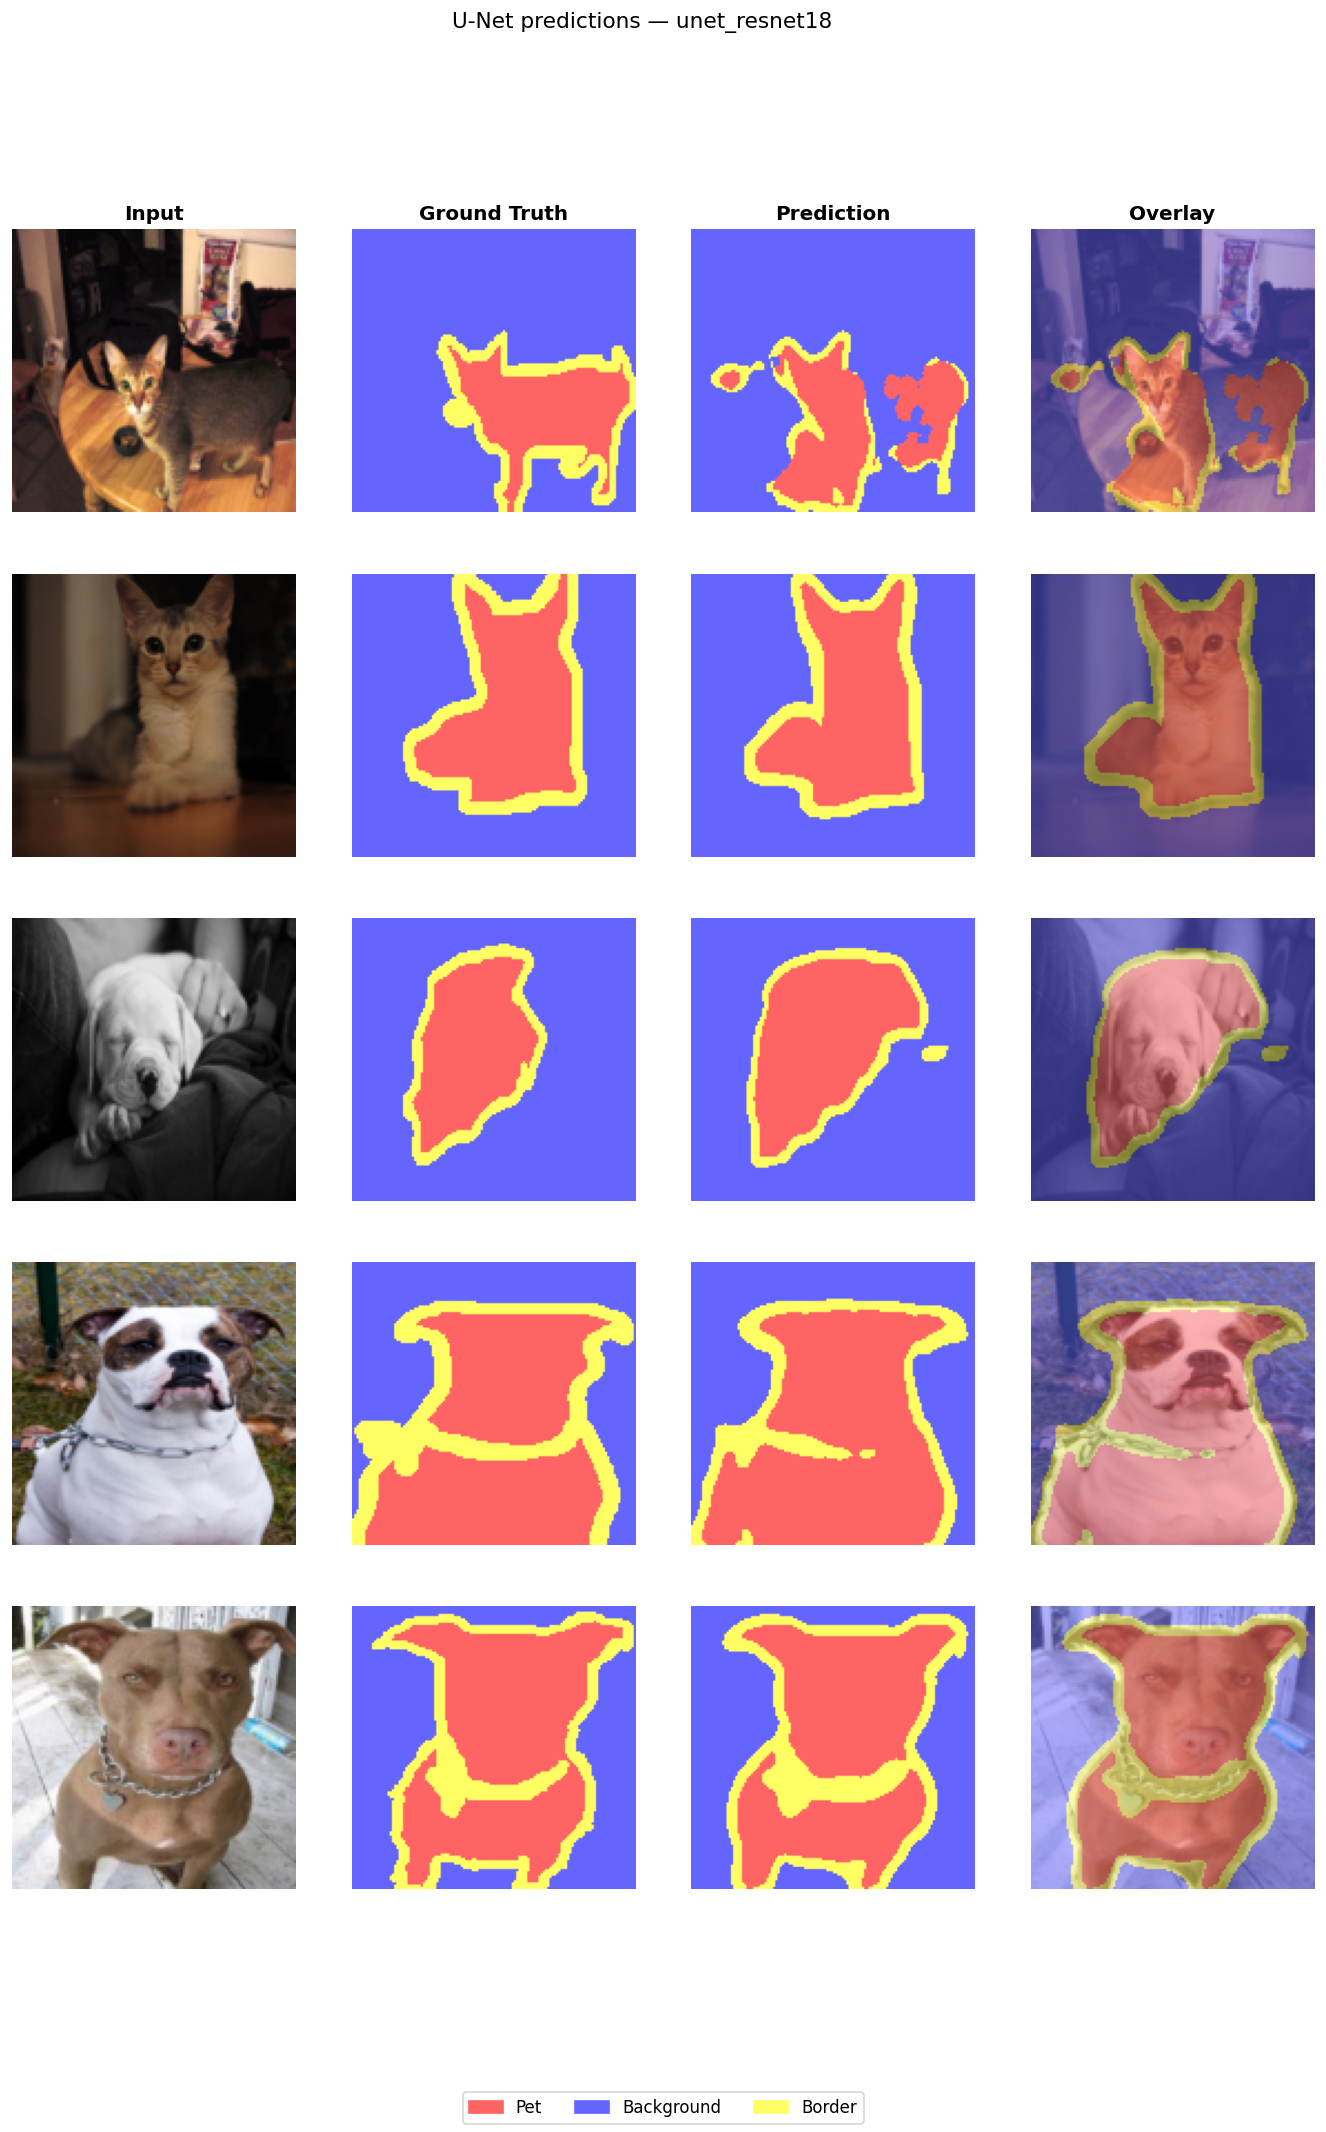

In [9]:
show('results/seg_pred_unet_resnet18.png', width=720)

### Predictions — no-skip variant

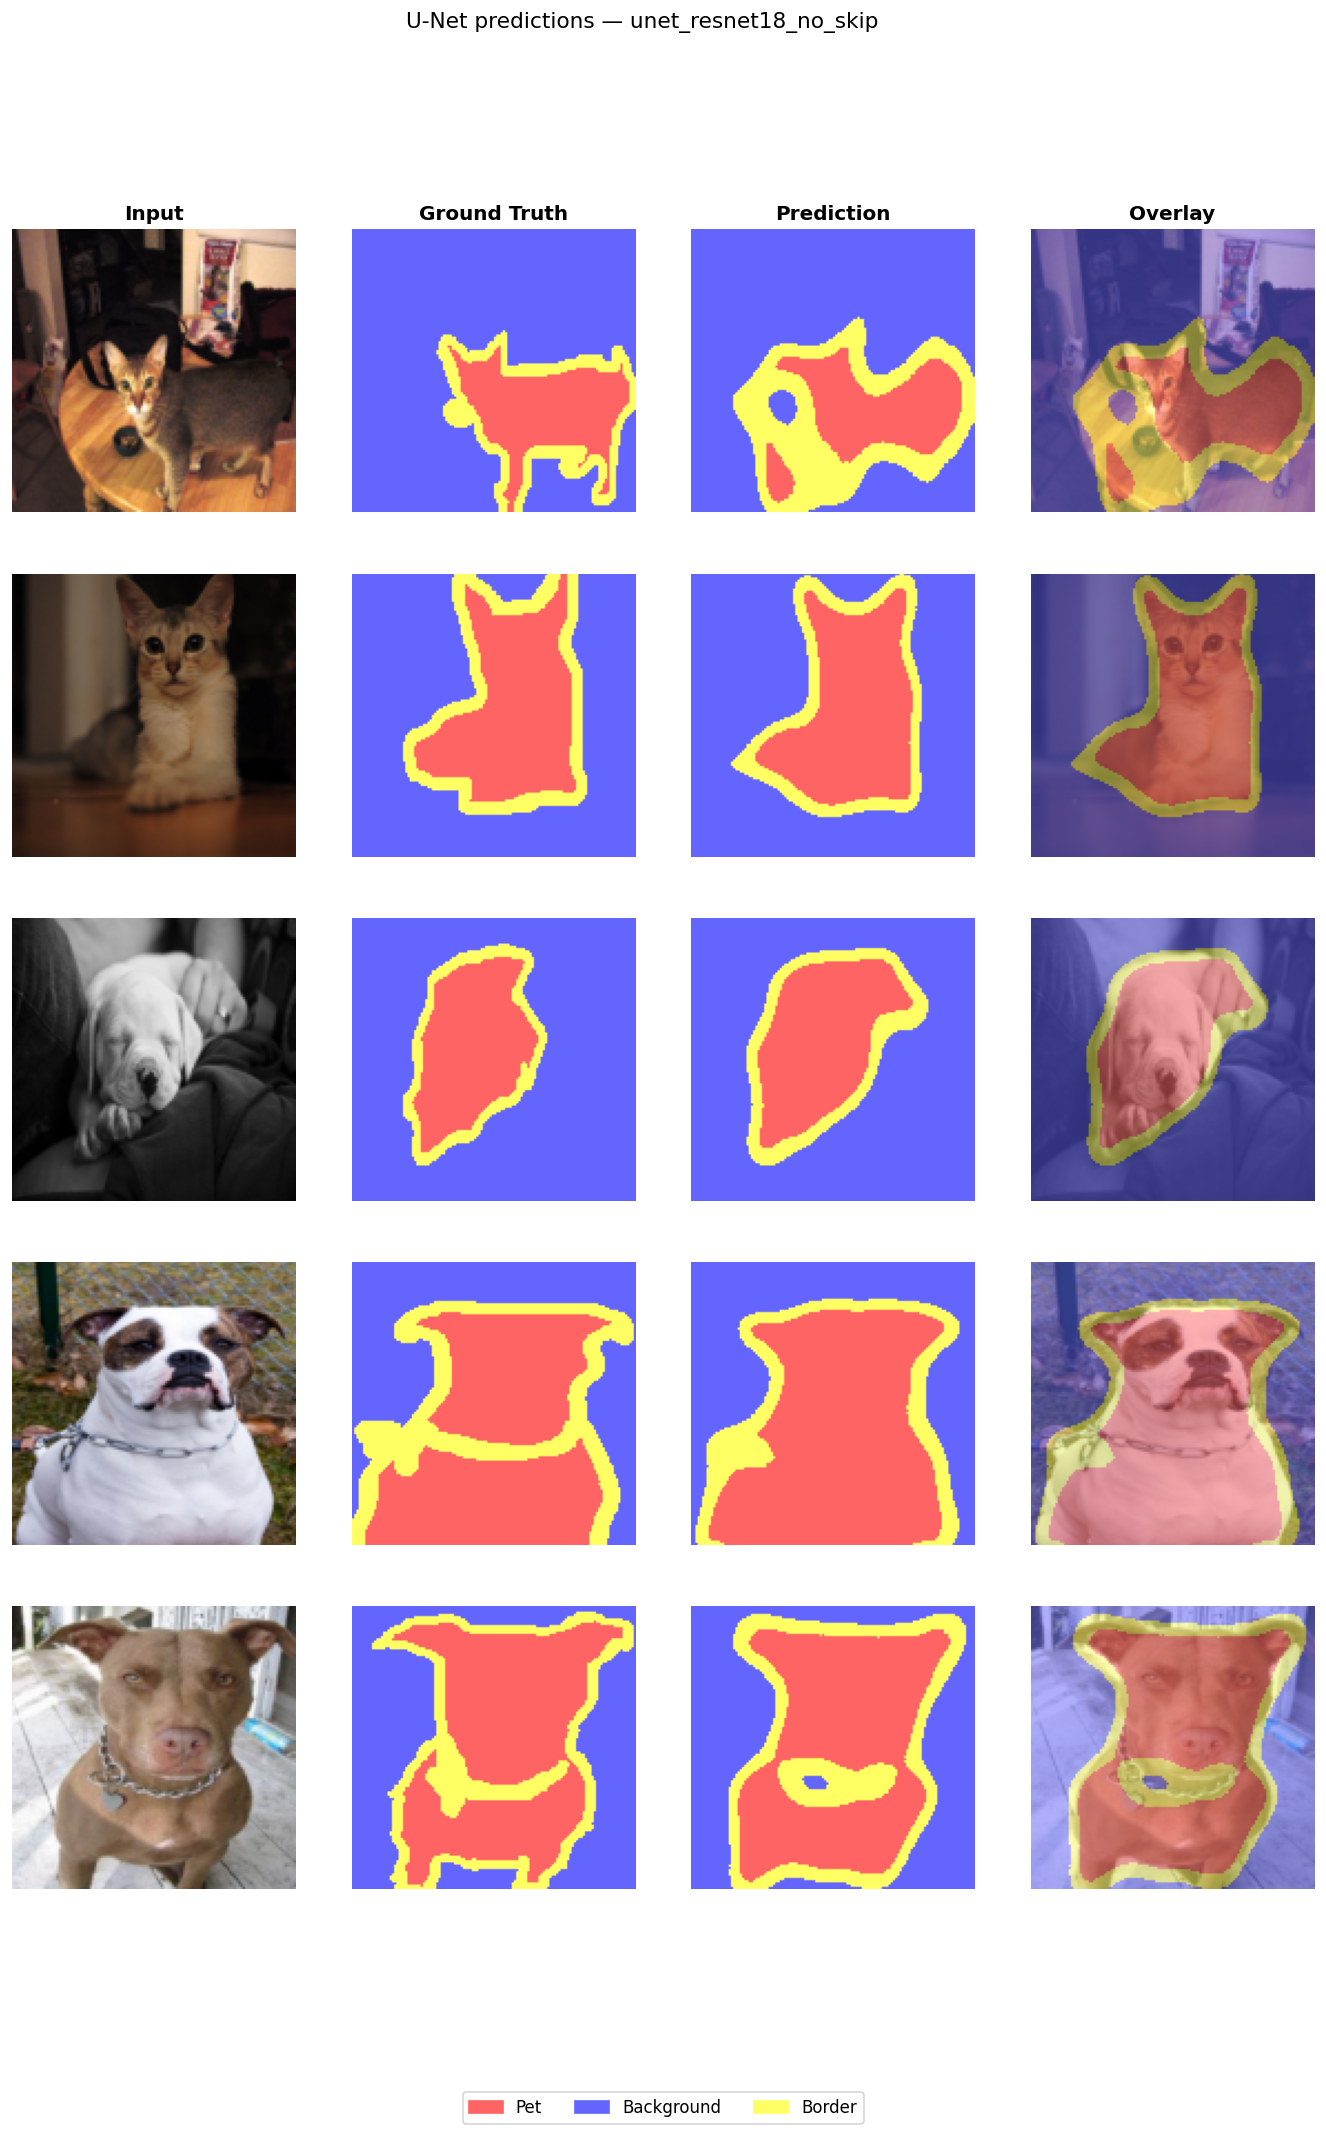

In [10]:
show('results/seg_pred_unet_resnet18_no_skip.png', width=720)

### Side by side (same images) — note how no-skip blurs boundaries

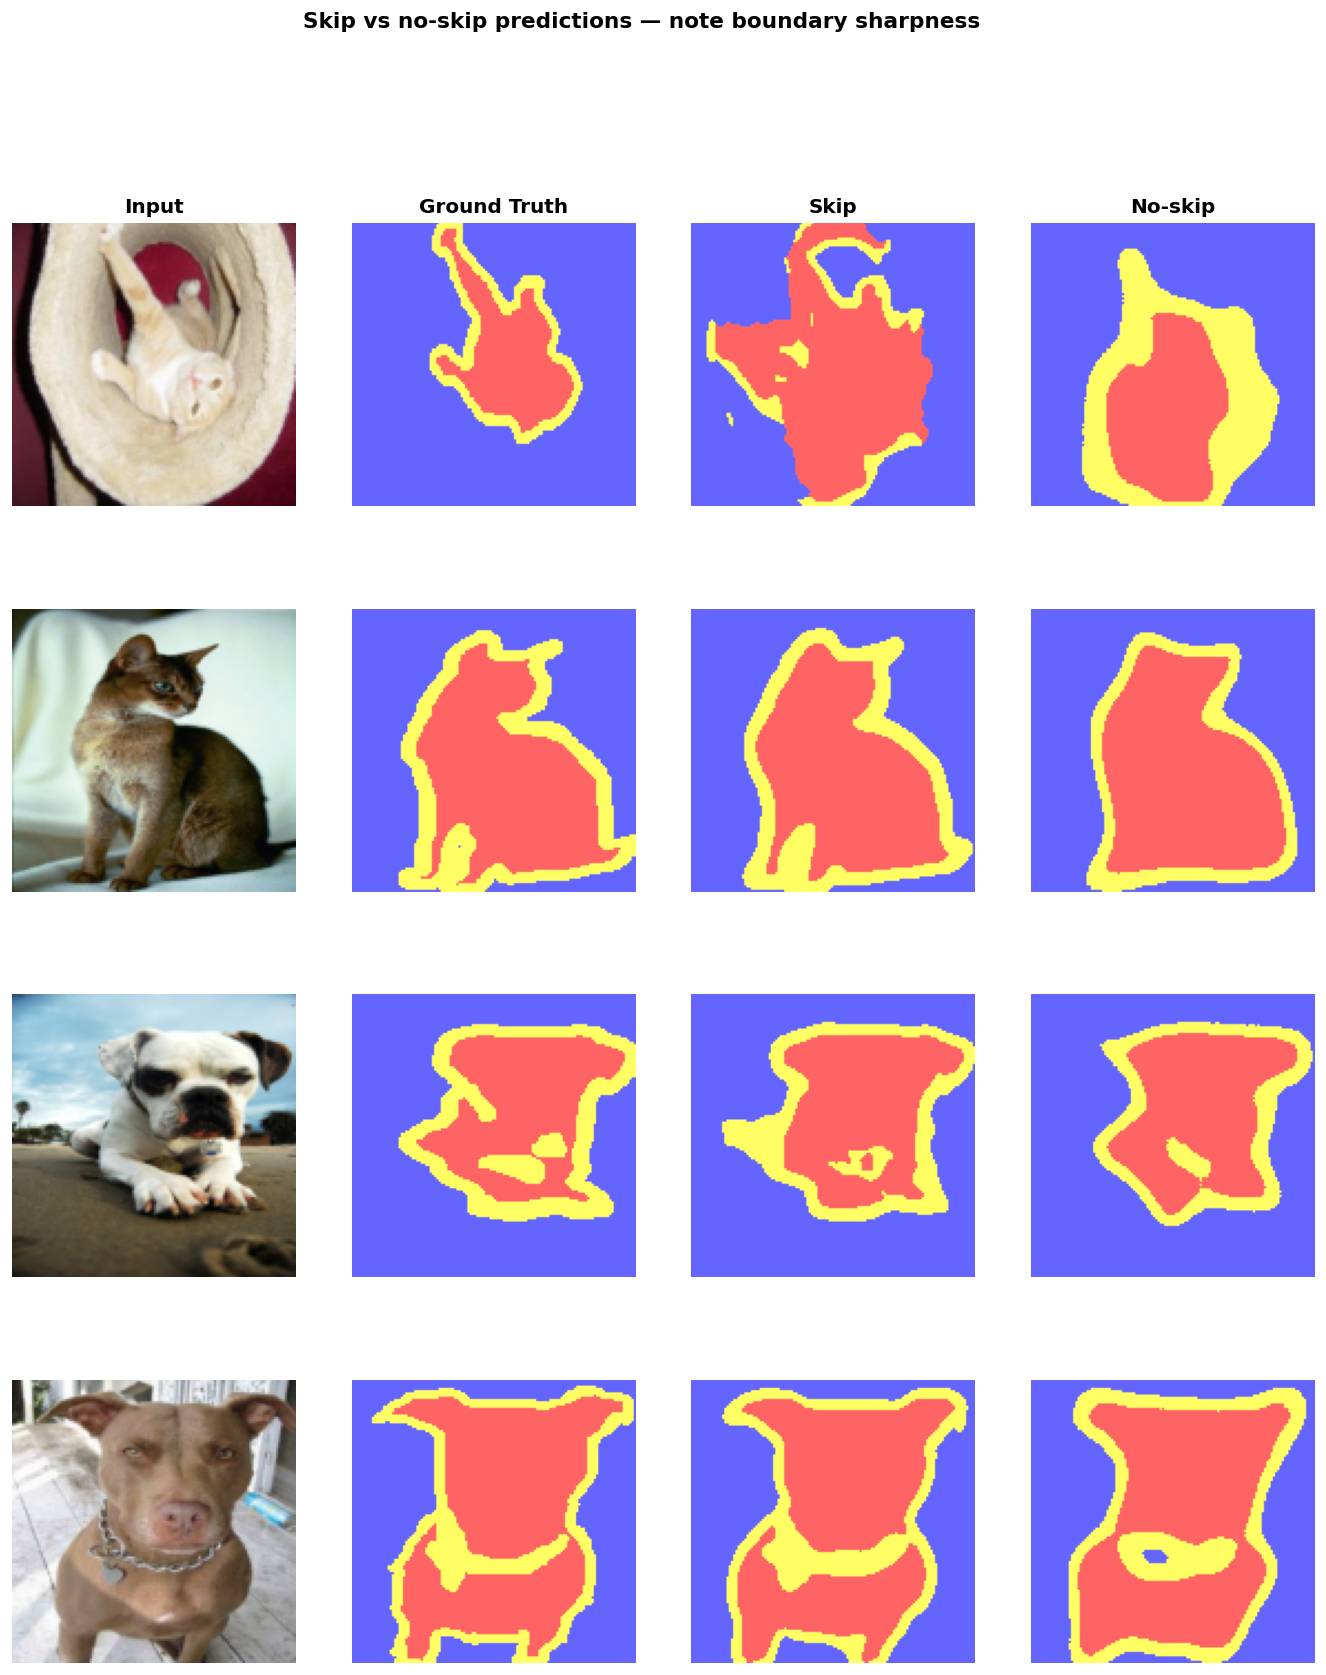

In [11]:
show('results/seg_skip_vs_noskip.png', width=820)

## 5. Exercise answers

### (c) Why do skip connections help segmentation more than classification?

Classification only needs *what* — a single global label — so the network deliberately discards spatial detail: pooling/striding build compact, translation-invariant semantics and the final answer doesn't depend on *where* an edge sat. Segmentation needs *what* **and** *exactly where* — a label per pixel — so the decoder must rebuild sharp boundaries at full resolution, which is impossible from the coarse bottleneck alone (a blurry thumbnail). Skip connections copy the encoder's high-resolution feature maps (precise edges/texture/location) straight into the decoder, fusing deep semantics with shallow geometry. For classification those shallow features barely affect the pooled prediction, so skips add little — they are far more valuable for dense prediction.

### (d) Which skip level hurts most when removed — first (64ch, highest res) or last (512ch, lowest res)?

The **first** skip (64-channel, H/2, highest resolution). It is the only path carrying full-resolution spatial detail into the final decoder stage; without it boundaries become blurry/blocky and thin structures (ear tips, legs, fur edges) are lost — precisely where pet IoU is decided. The last skip (512-channel, H/32) carries deep semantics that the adjacent bottleneck *already* encodes, so removing it is largely redundant. The highest-resolution skip supplies information available nowhere else in the decoder; the lowest-resolution one duplicates the bottleneck.

## 6. Discussion

Skip connections lift Val mIoU by the amount shown in the table above, and the side-by-side panels show the gain is concentrated at object **boundaries** (the Border/Pet classes) — the no-skip decoder must hallucinate fine edges from a coarse bottleneck and produces rounded, leaky masks. **Choose U-Net** when you need dense per-pixel labels for one or a few classes and don't need to separate instances — medical organ/tumour masks, road/sky 'stuff' — especially with limited data and a pretrained encoder. **Choose Mask R-CNN** when you must detect, separate and count individual object **instances** (this cat vs that cat) and also want boxes + labels, accepting its heavier two-stage cost.